In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Data Loading From Excel
# 10,000 + rows Import

Data = r"D:\career247\02 - Data for python.xlsx"
print(pd.read_excel(Data))

      Row ID        Order ID Order Date  Ship Date       Ship Mode  \
0       7981  CA-2011-103800 2013-01-03 2013-01-07  Standard Class   
1        740  CA-2011-112326 2013-01-04 2013-01-08  Standard Class   
2        741  CA-2011-112326 2013-01-04 2013-01-08  Standard Class   
3        742  CA-2011-112326 2013-01-04 2013-01-08  Standard Class   
4       1760  CA-2011-141817 2013-01-05 2013-01-12  Standard Class   
...      ...             ...        ...        ...             ...   
9989     908  CA-2014-143259 2016-12-30 2017-01-03  Standard Class   
9990     909  CA-2014-143259 2016-12-30 2017-01-03  Standard Class   
9991    1297  CA-2014-115427 2016-12-30 2017-01-03  Standard Class   
9992    1298  CA-2014-115427 2016-12-30 2017-01-03  Standard Class   
9993    5092  CA-2014-156720 2016-12-30 2017-01-03  Standard Class   

     Customer ID      Customer Name      Segment        Country  \
0       DP-13000      Darren Powers     Consumer  United States   
1       PO-19195      Phi

In [11]:
# Load Excel Sheets

print("--- Orders Dataset Overview ---")
orders_df = pd.read_excel(Data, sheet_name='Orders')
print(orders_df.info())

print("--- Returns Dataset Overview ---")
returns_df = pd.read_excel(Data, sheet_name='Returns')
print(returns_df.info())

print("--- People Dataset Overview ---")
people_df = pd.read_excel(Data, sheet_name='People')
print(people_df.info())

--- Orders Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object   

In [16]:
# Data Cleaning And Feature Engineering
print("\n--- Data Cleaning & Validation ---")

# Check missing values and duplicates
print("Missing values in Orders:", orders_df.isnull().sum().sum())
print("Duplicate rows in Orders:", orders_df.duplicated().sum())


--- Data Cleaning & Validation ---
Missing values in Orders: 0
Duplicate rows in Orders: 0


In [18]:
# Date conversions
orders_df['Order Date'] = pd.to_datetime(orders_df['Order Date'])
orders_df['Ship Date'] = pd.to_datetime(orders_df['Ship Date'])

In [20]:
# To See the Data Type In Orders Table
# print(orders_df.info())

In [21]:
# Shipping Duration in Days
# Minus Ship Date & Order Date

orders_df['Shipping Duration'] = (orders_df['Ship Date'] - orders_df['Order Date']).dt.days

In [22]:
# Feature Engineering: Profit Margin (%)
orders_df['Profit Margin (%)'] = np.where(
    orders_df['Sales'] > 0, 
    (orders_df['Profit'] / orders_df['Sales']) * 100, 
    0
)

In [26]:
# Feature Engineering: Extract Order Year & Month
# Standardizes order timestamps into YYYY-MM format to enable monthly trend reporting.

orders_df['Order Year'] = orders_df['Order Date'].dt.year
orders_df['Order Month'] = orders_df['Order Date'].dt.strftime('%Y-%m')

In [29]:
# Merge with Returns dataset
# Left Join with Returns: Retains all order records while flagging orders that appear in the returns sheet.
# Missing matches (NaN) are filled with 'No'.
merged_df = orders_df.merge(returns_df, left_on='Order ID', right_on='Updated Order Returns', how='left')
merged_df['Returned'] = merged_df['Returned'].fillna('No')

In [35]:
print(returns_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Returned               296 non-null    object
 1   Updated Order Returns  296 non-null    object
dtypes: object(2)
memory usage: 4.8+ KB
None


In [30]:
# Merge with Regional Managers (People sheet)
# Left Join with People: Attaches the responsible Regional Manager's name to each transaction based on region.
final_df = merged_df.merge(people_df, on='Region', how='left')

In [42]:
print(people_df.head())

              Person   Region
0      Anna Andreadi     West
1        Chuck Magee     East
2     Kelly Williams  Central
3  Cassandra Brandow    South


In [43]:
# Cleaned & Merged Data Head
print("\n--- Cleaned & Merged Data Head ---")
print(final_df[['Order ID', 'Category', 'Sales', 'Profit', 'Shipping Duration', 'Returned', 'Person']].head())


--- Cleaned & Merged Data Head ---
         Order ID         Category    Sales   Profit  Shipping Duration  \
0  CA-2011-103800  Office Supplies   16.448   5.5512                  4   
1  CA-2011-112326  Office Supplies   11.784   4.2717                  4   
2  CA-2011-112326  Office Supplies  272.736 -64.7748                  4   
3  CA-2011-112326  Office Supplies    3.540  -5.4870                  4   
4  CA-2011-141817  Office Supplies   19.536   4.8840                  7   

  Returned          Person  
0       No  Kelly Williams  
1       No  Kelly Williams  
2       No  Kelly Williams  
3       No  Kelly Williams  
4       No     Chuck Magee  


In [74]:
# Exploratory Data Analysis
print("     KEY BUSINESS METRICS SUMMARY     ")

total_sales = final_df['Sales'].sum()
total_profit = final_df['Profit'].sum()
total_orders = final_df['Order ID'].nunique()
overall_margin = (total_profit / total_sales) * 100
avg_discount = final_df['Discount'].mean() * 100

# print(total_sales)
# print(total_profit)
# print(total_orders)
# print(overall_margin)
# print(avg_discount)

print("Total Sales $ = ", round(total_sales,2))
print("Total Profit $ = ", round(total_profit,2))
print("Total Orders =", round(total_orders,2))
print("Overall Margins = ", round(overall_margin,2),"%")
print("Average Discounts = ", round(avg_discount,2),"%")

     KEY BUSINESS METRICS SUMMARY     
Total Sales $ =  2297200.86
Total Profit $ =  286397.02
Total Orders = 5009
Overall Margins =  12.47 %
Average Discounts =  15.62 %


In [79]:
# Category Breakdown
print("--- Performance by Category ---")

category_summary = final_df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_Discount=('Discount', 'mean')
).reset_index()

print(category_summary)

--- Performance by Category ---
          Category  Total_Sales  Total_Profit  Total_Quantity  Avg_Discount
0        Furniture  741999.7953    18451.2728            8028      0.173923
1  Office Supplies  719047.0320   122490.8008           22906      0.157285
2       Technology  836154.0330   145454.9481            6939      0.132323


In [87]:
# Discount vs Profitability Analysis
print("--- Profitability by Discount Tier ---")
discount_impact = final_df.groupby('Discount').agg(
    Avg_Profit=('Profit', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Order_Count=('Row ID', 'count')
).reset_index()

#print(discount_impact.head(10))
print(discount_impact.to_string())

--- Profitability by Discount Tier ---
    Discount  Avg_Profit   Total_Sales  Order_Count
0       0.00   66.900292  1.087908e+06         4798
1       0.10   96.055074  5.436935e+04           94
2       0.15   27.288298  2.755852e+04           52
3       0.20   24.702572  7.645944e+05         3657
4       0.30  -45.679636  1.032267e+05          227
5       0.32  -88.560656  1.449346e+04           27
6       0.40 -111.927429  1.164178e+05          206
7       0.45 -226.646464  5.484974e+03           11
8       0.50 -310.703456  5.891854e+04           66
9       0.60  -43.077212  6.644700e+03          138
10      0.70  -95.874060  4.062028e+04          418
11      0.80 -101.796797  1.696376e+04          300


In [91]:
# DATA VISUALIZATION

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

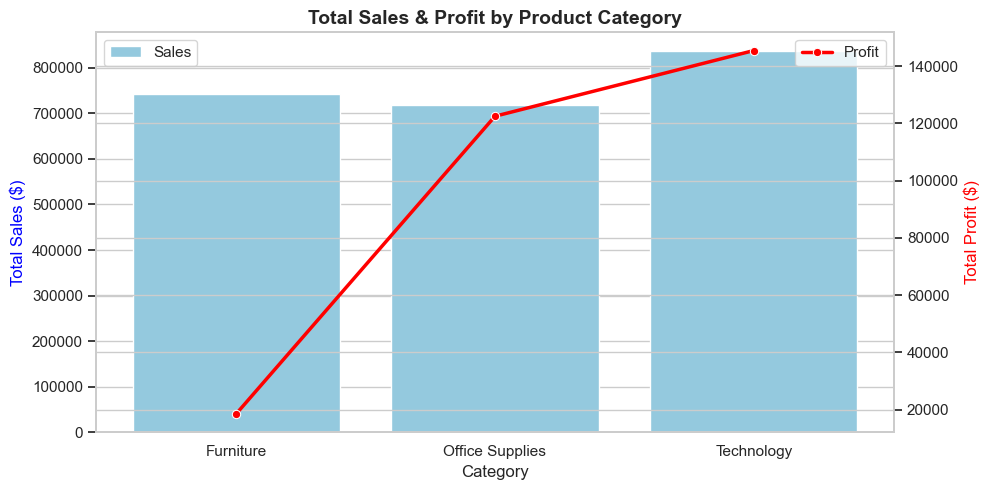

In [92]:
# Chart 1: Sales & Profit by Category
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(data=category_summary, x='Category', y='Total_Sales', ax=ax1, color='skyblue', label='Sales')
ax2 = ax1.twinx()
sns.lineplot(data=category_summary, x='Category', y='Total_Profit', ax=ax2, color='red', marker='o', linewidth=2.5, label='Profit')

ax1.set_ylabel('Total Sales ($)', color='blue')
ax2.set_ylabel('Total Profit ($)', color='red')
plt.title('Total Sales & Profit by Product Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

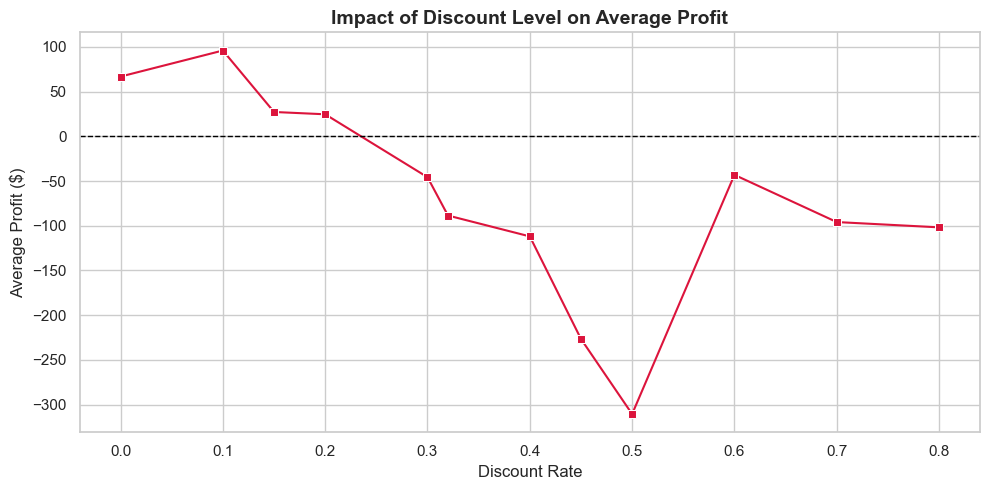

In [93]:
# Chart 2: Profit vs. Discount Level
plt.figure(figsize=(10, 5))
sns.lineplot(data=final_df, x='Discount', y='Profit', estimator='mean', ci=None, color='crimson', marker='s')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Impact of Discount Level on Average Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Average Profit ($)')
plt.tight_layout()
plt.show()

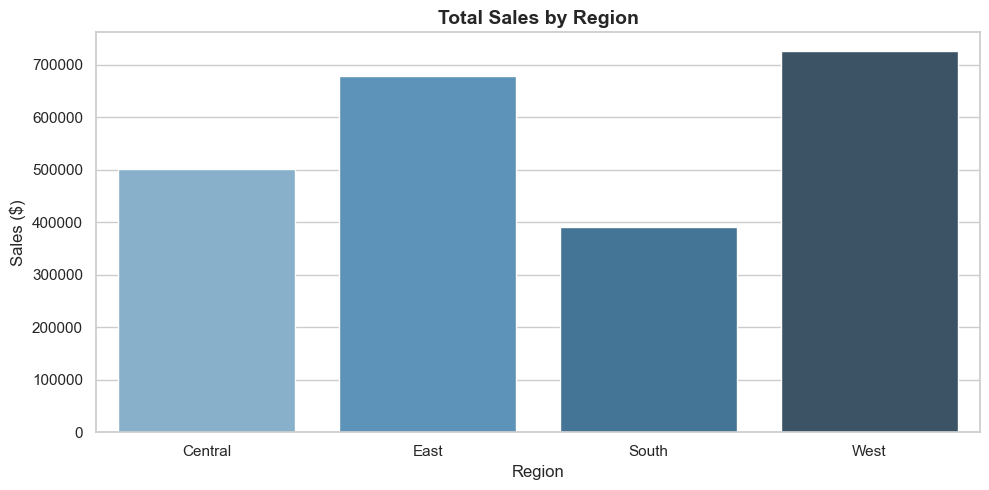

In [94]:
# Chart 3: Regional Sales Performance
plt.figure(figsize=(10, 5))
region_sales = final_df.groupby('Region')['Sales'].sum().reset_index()
sns.barplot(data=region_sales, x='Region', y='Sales', palette='Blues_d')
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

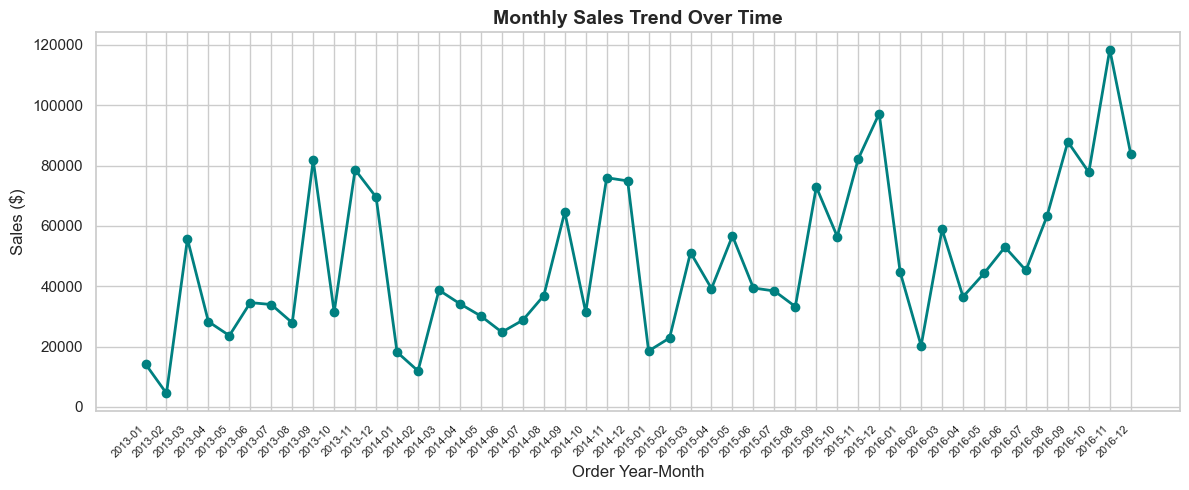

In [95]:
# Chart 4: Monthly Sales Trend
plt.figure(figsize=(12, 5))
monthly_trend = final_df.groupby('Order Month')['Sales'].sum().reset_index()
plt.plot(monthly_trend['Order Month'], monthly_trend['Sales'], marker='o', color='teal', linewidth=2)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Order Year-Month')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

In [ ]:
# Creating HEATMAP

In [96]:
# 1. Create Acquisition Cohort (Month of First Purchase)
final_df['OrderPeriod'] = final_df['Order Date'].dt.to_period('M')
final_df['Cohort'] = final_df.groupby('Customer ID')['Order Date'].transform('min').dt.to_period('M')

In [98]:
# 2. Aggregate Data by Cohort and OrderPeriod
cohort_data = final_df.groupby(['Cohort', 'OrderPeriod']).agg(
    Total_Users=('Customer ID', 'nunique')
).reset_index()

In [99]:
# 3. Calculate Cohort Period Index (e.g., Month 0, Month 1, Month 2...)
cohort_data['CohortIndex'] = (cohort_data['OrderPeriod'] - cohort_data['Cohort']).apply(lambda x: x.n)

In [104]:
# 4. Pivot Data for Heatmap
cohort_pivot = cohort_data.pivot(index='Cohort', columns='CohortIndex', values='Total_Users')
print(cohort_pivot.head())

CohortIndex    0    1    2    3     4    5     6     7    8    9   ...    38  \
Cohort                                                             ...         
2013-01      32.0  3.0  NaN  2.0   2.0  NaN   2.0   4.0  5.0  3.0  ...   6.0   
2013-02      24.0  4.0  2.0  1.0   NaN  2.0   2.0   3.0  3.0  4.0  ...   2.0   
2013-03      65.0  4.0  2.0  8.0   7.0  NaN   7.0   5.0  8.0  6.0  ...  13.0   
2013-04      56.0  6.0  2.0  4.0   3.0  8.0   6.0   9.0  8.0  1.0  ...   5.0   
2013-05      56.0  5.0  5.0  4.0  10.0  2.0  12.0  10.0  4.0  3.0  ...   7.0   

CohortIndex    39    40    41    42    43    44    45    46   47  
Cohort                                                            
2013-01       4.0   5.0   4.0   1.0   2.0   9.0   9.0  10.0  6.0  
2013-02       2.0   5.0   3.0   3.0   4.0   6.0   6.0   3.0  NaN  
2013-03      10.0  12.0   6.0  19.0   8.0  18.0  16.0   NaN  NaN  
2013-04       7.0   8.0  15.0   8.0  14.0  14.0   NaN   NaN  NaN  
2013-05       6.0  16.0   7.0  17.0  

In [105]:
# 5. Calculate Retention Percentage (Divide by Month 0 size)
cohort_sizes = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

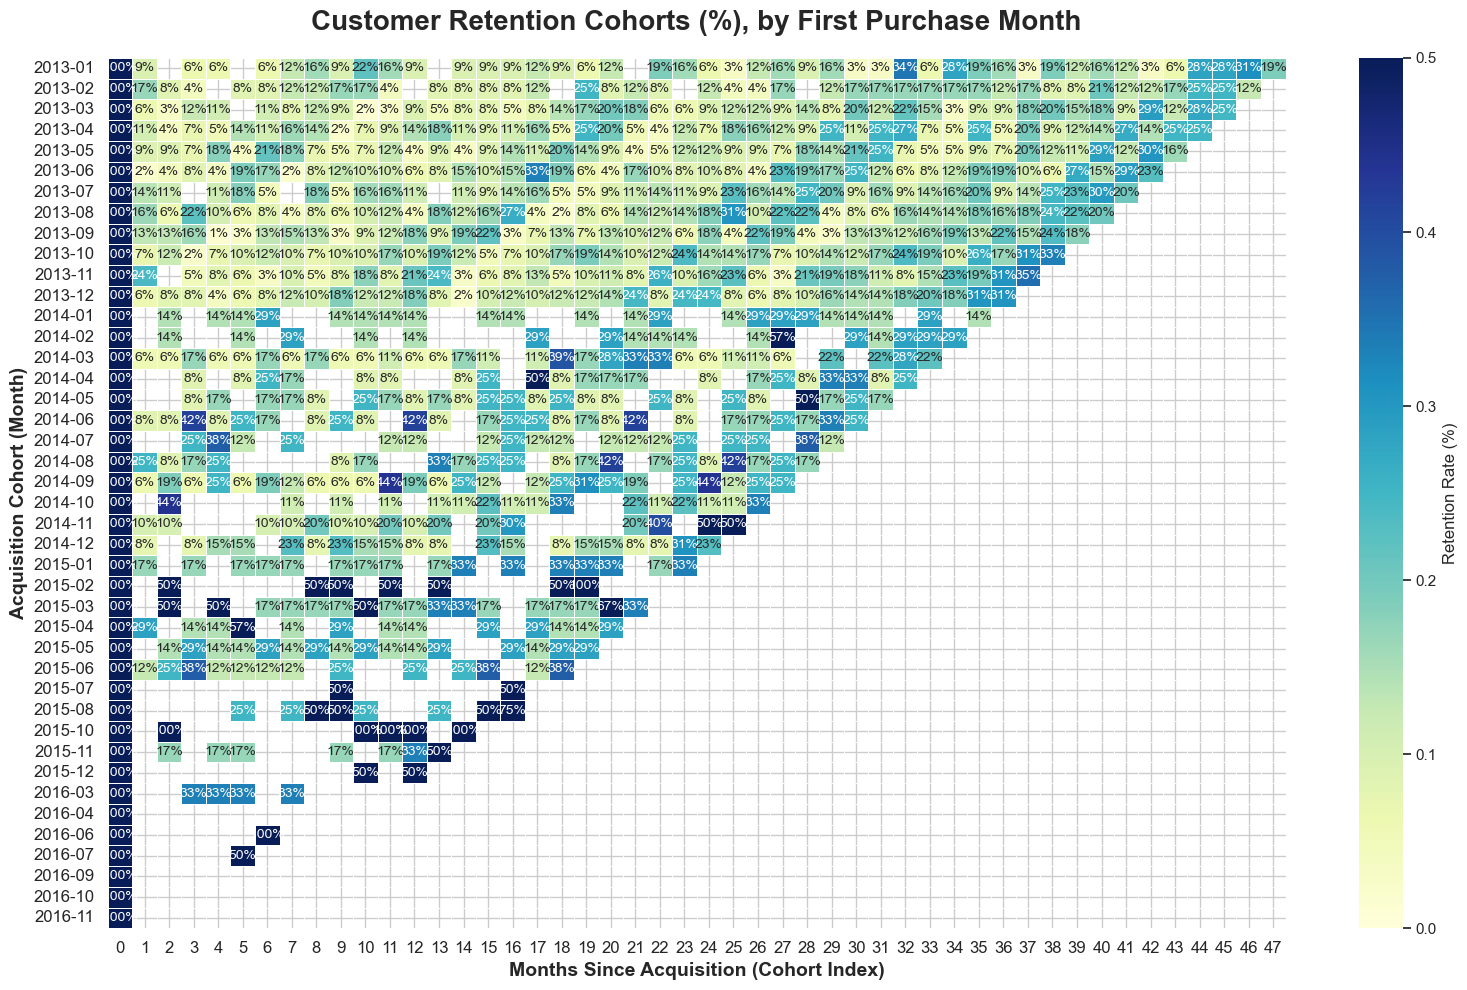

In [106]:
# 6. Plotting Retention Heatmap
plt.figure(figsize=(16, 10))
plt.title('Customer Retention Cohorts (%), by First Purchase Month', fontsize=20, fontweight='bold', pad=20)

sns.heatmap(retention_matrix, 
            annot=True, 
            fmt='.0%', 
            cmap='YlGnBu', 
            vmin=0.0, vmax=0.5, # Cap at 50% for color scaling granularity
            cbar_kws={'label': 'Retention Rate (%)'},
            linewidths=.5)

plt.xlabel('Months Since Acquisition (Cohort Index)', fontsize=14, fontweight='bold')
plt.ylabel('Acquisition Cohort (Month)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=300) # Higher DPI for portfolio
plt.show()